
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

## Solución

Como sólo nos interesa la solución radial, no nos centraremos en la parte angular, simplemente tomaremos el hecho de que los autovalores vienen dados por $l(l + 1)$. Así,

$$
\begin{align*}
-\dfrac{\hbar^2}{2m} \left[ \dfrac{1}{r^2} \dfrac{\partial}{\partial r} \left( r^2 \dfrac{\partial \psi(\vec{r})}{\partial r} \right) 
- \dfrac{l (l + 1)}{r^2} \psi(\vec{r}) \right]
-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r}) &= \\
-\dfrac{\hbar^2}{2m} \left(\dfrac{\partial^2 \psi(\vec{r})}{\partial r^2} + \dfrac{2}{r} \dfrac{\partial \psi(\vec{r})}{\partial r} 
- \dfrac{l (l + 1)}{r^2} \psi(\vec{r}) \right)
-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r}) &=  E\,\psi(\vec{r})
\end{align*}
$$

Al haber solo una variable, cambiemos $\vec{r}$ por $x$ y las derivadas parciales por totales:
$$
-\dfrac{\hbar^2}{2m} \left(\dfrac{d^2 \psi(x)}{d x^2} + \dfrac{2}{x} \dfrac{d \psi(x)}{d x} - \dfrac{l (l + 1)}{x^2} \psi(x)\right)
-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{x}\psi(x) =  E\,\psi(x)
$$

No voy a escribir el desarrollo pues la verdad me da mucho tedio escribir $\LaTeX$, pero al hacer la sustitución $\psi(x) = u(x) / x$ se elimina la primera derivada, haciendo que la ecuación resulte en:
$$
-\dfrac{\hbar^2}{2m} \dfrac{d^2 u(x)}{d x^2}
+ \left[ \dfrac{\hbar^2}{2 m}\dfrac{l(l+1)}{x^2} -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{x} \right] u(x) =  E\, u(x)
$$

El término entre corchetes lo podemos tomar como un potencial efectivo $V(x)$.  
Ahora, supongamos una diferencia $\Delta x$ pequeña y aproximemos la segunda derivada:

$$
-\dfrac{\hbar^2}{2m} \dfrac{u(x + \Delta x) + u(x - \Delta x) - 2 u(x)}{(\Delta x)^2} 
+ V(x) u(x) =  E\, u(x)
$$

Si $k =\dfrac{2m(\Delta x)^2}{\hbar^2}$, $u(x)= u_i$, $V(x)= \dfrac{\hbar^2}{2m}\dfrac{l(l+1)}{x^2}-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{x} = V_i$ entonces

$$-\dfrac{1}{k} u_{i-1}
+ \dfrac{1}{k}\bigg(2 + k\,V_i\bigg) u_i
-\dfrac{1}{k} u_{i+1}
\approx E\, u_i
$$


Está claro que para $x = 0$ la densidad de probabilidad debe de anularse. Como trabajaré en [unidades atómicas](https://en.wikipedia.org/wiki/Atomic_units), las medidas en $x$ estarán dadas en radios de Bohr, por lo que si tomamos $x = 30 n^2$ como cota superior donde la densidad de probabilidad debe anularse, no estaremos anulando incorrectamente parte de la función de onda. El $n^2$ lo pongo debido a que las densidades de probabilidad se hacen más anchas a medida que se aumenta el nivel de energía.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

In [57]:
rmin = 1e-5
rmax = 50
N = 1000

x = np.linspace(rmin, rmax, N)

def FDM_Matrix(x, U, k, l=0):
    n = len(x)
    V = np.zeros((n, n))

    V[0, 0] = 2 + k * U(x[0], l)

    for i in range(1, n):
        V[i, i] = 2 + k * U(x[i], l)
        V[i - 1, i] = -1
        V[i, i - 1] = -1

    return V


def radial_sol(x, l):
    dx = x[1] - x[0]
    k = 2 * dx * dx

    xi = x[1:-1] # para mantener las condiciones de frontera

    # Como las unidades son atómicas, todo lo que acompaña al 1/x es igual a 1
    V = lambda x, l: l*(l + 1) / (2*x*x) - 1 / x
    M = FDM_Matrix(xi, V, k, l) / k

    E, u_interior = np.linalg.eigh(M) # eigh porque la matriz es simétrica

    mask = E < 0

    E_real = E[mask]
    u_interior = u_interior[:, mask]

    # Acá u_real siempre va a tener ceros en el primer y último índice
    u_real = np.zeros((len(E_real), len(x)))
    u_real[:, 1:-1] = u_interior.T

    for i, u in enumerate(u_real):
        area = np.trapezoid(u**2, x)
        u_real[i] /= np.sqrt(area)

    return E_real, u_real

Los estados ligados del átomo de hidrógeno siempre tienen energía negativa, y se van acercando poco a poco al cero [1]. Teniendo esto en cuenta, los resultados que den autovalores $E \gt 0$ no serán tomados en cuenta pues no tienen relevancia en este problema. En principio, si se tomara un `rmax` infinitamente grande, todos los autovalores darían números negativos; es el hecho de tener una cota superior en la distancia lo que hace que los resultados pierdan significancia física.

Por otra parte, nótese que el primer valor es gigantesco: esto es un artefacto numérico, y lo eliminaré para los siguientes pasos.

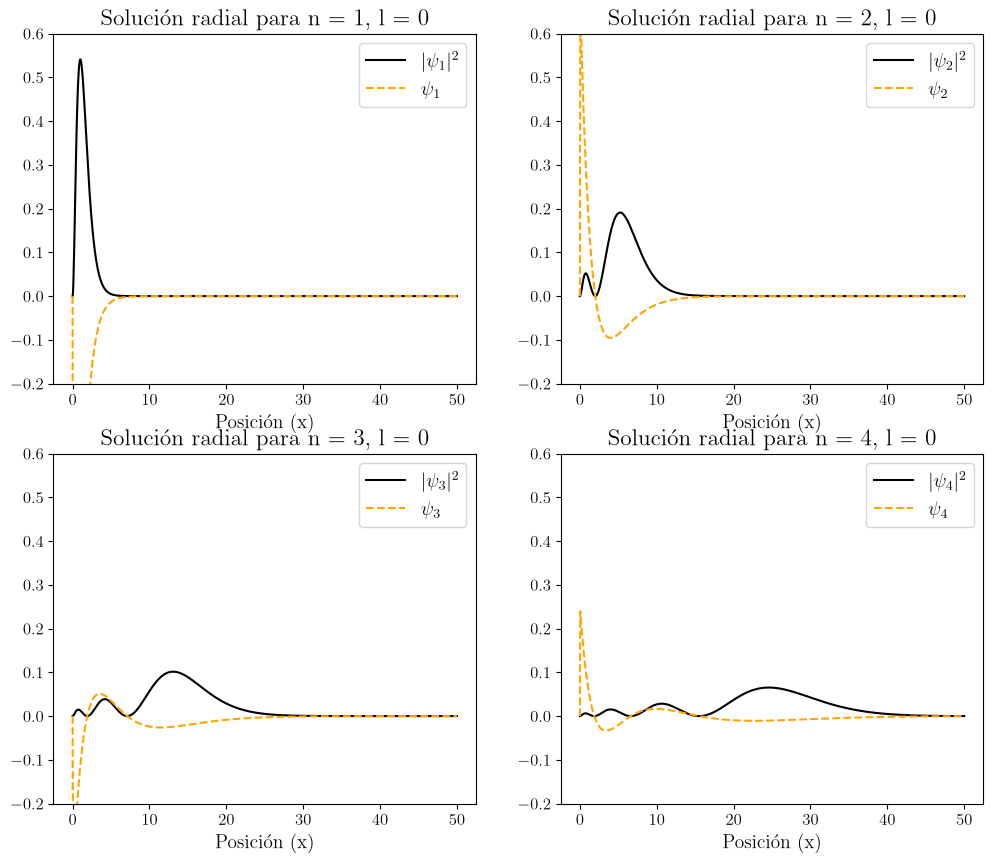

In [58]:
E_real, u_real = radial_sol(x, 0)
psi = u_real / x

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs_flat = axs.flatten()

for i, ax in enumerate(axs_flat):
    ax.plot(x, u_real[i]**2, label=f"$|\\psi_{i + 1}|^2$", color="black")
    ax.plot(x, psi[i], "--", label=f"$\\psi_{i + 1}$", color="orange")
    ax.set_xlabel("Posición (x)")
    ax.set_title(f"Solución radial para n = {i+1}, l = 0")
    ax.set_ylim((-0.2, 0.6))
    ax.legend()

plt.show()


In [56]:
E0 = -13.6 # eV
print("Energías en unidades de eV, obtenidas numéricamente comparadas con las teóricas")
# Para la conversión de unidades, ver referencia 2
for i, E in enumerate(E_real):
    E_num = E * 27.211
    E_teo = E0 / ((i + 1)**2)
    print(f"E_{i + 1} (numérico) = {E_num:.3f} eV \t E_{i + 1} (teórico) = {E_teo:.3f} \t diff = {abs(E_num - E_teo)}")

Energías en unidades de eV, obtenidas numéricamente comparadas con las teóricas
E_1 (numérico) = -13.596 eV 	 E_1 (teórico) = -13.600 	 diff = 0.0035267798895919356
E_2 (numérico) = -3.401 eV 	 E_2 (teórico) = -3.400 	 diff = 0.000777935584553191
E_3 (numérico) = -1.512 eV 	 E_3 (teórico) = -1.511 	 diff = 0.00048654967153494155
E_4 (numérico) = -0.849 eV 	 E_4 (teórico) = -0.850 	 diff = 0.0009408164193731583
E_5 (numérico) = -0.486 eV 	 E_5 (teórico) = -0.544 	 diff = 0.057909962294129036
E_6 (numérico) = -0.062 eV 	 E_6 (teórico) = -0.378 	 diff = 0.3161450917036195


Las energías dan un muy buen resultado, sobre todo las primeras. Si se aumentara el parámetro `rmax` y el número de puntos del grid seguramente se lograría tener más energías y con cada vez mayor precisión. 

Las funciones de onda se ven feas por la inestabilidad numérica al dividir por números tan cercanos al cero. Por su parte, las densidades de probabilidad se asemejan visualmente bastante a las que se mostraron en el notebook 2.3.  No hice un chequeo formal ni exhaustivo, pero quedo contento con el resultado.

Por último, voy a graficar los primeros 3 estados de energía para $l = 1, 2, 3, 4$. Solo las densidades de probabilidad, pues se ve más lindo.

[]

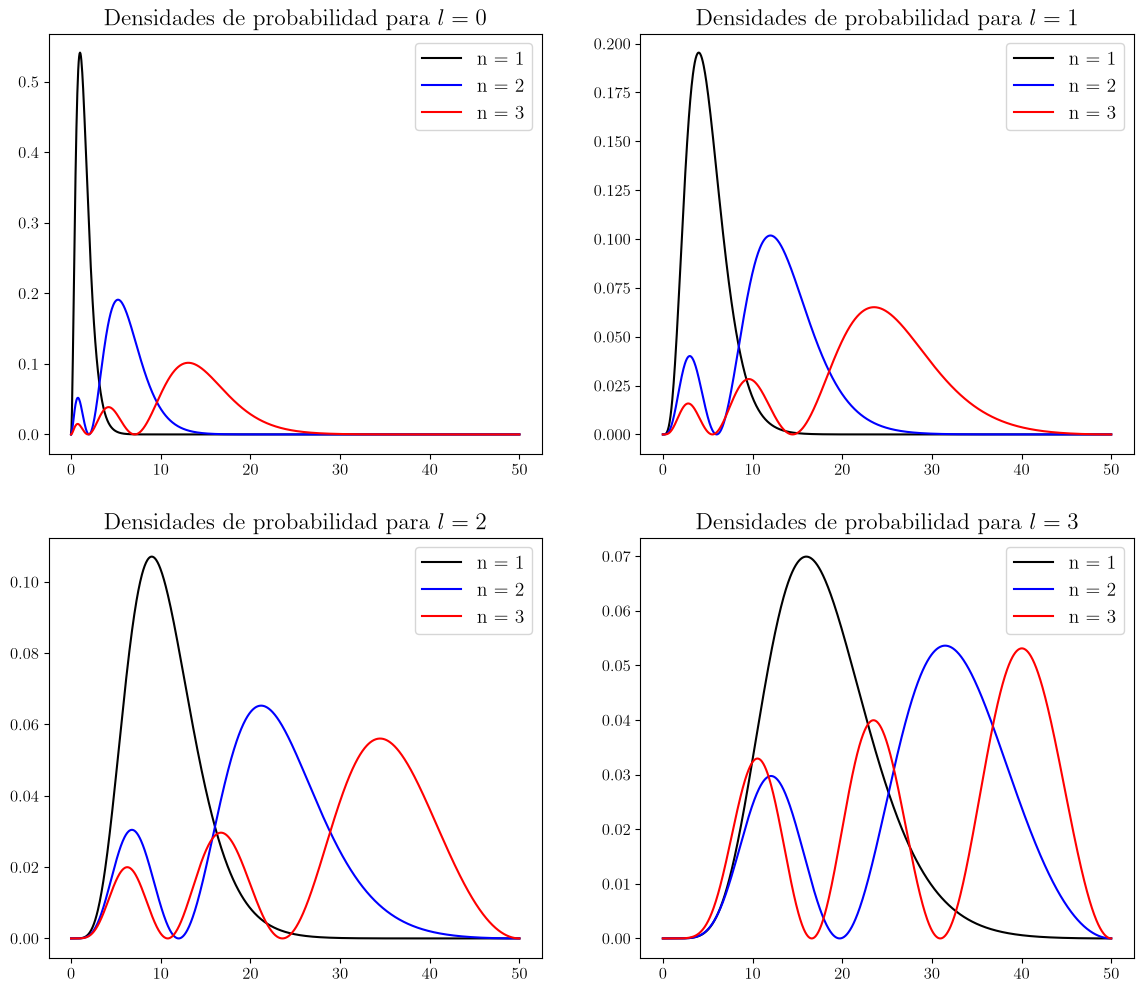

In [63]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs_flat = axs.flatten()

for i, ax in enumerate(axs_flat):
    E, u = radial_sol(x, i)
    ax.plot(x, u[0]**2, color="black", label=f"n = 1")
    ax.plot(x, u[1]**2, color="blue", label=f"n = 2")
    ax.plot(x, u[2]**2, color="red", label=f"n = 3")
    ax.set_title(f"Densidades de probabilidad para $l = {i}$")
    ax.legend()

plt.plot()

Entre mayor es el $l$, mayor es el espacio necesario para la solución. Sería más correcto aumentar el tamaño del array x según se aumente tanto $l$ como $n$, pero de todas formas así como está da un buen resultado.

## Referencias

[1] https://farside.ph.utexas.edu/teaching/qm/Quantum/node44.html  
[2] https://es.wikipedia.org/wiki/Hartree